# Linda Bradford Raschke (LBR) 3/10 Anti Setup — Algorithm Walkthrough

### What we cover

| # | Section | What it does |
|---|---------|-------------|
| 1 | **Fetch data** | Pull 120 daily bars from Alpaca for any symbol |
| 2 | **ADX(14)** | Measure trend strength — blocks strong-trend markets |
| 3 | **EMA(20)** | Trend direction filter — long-only above the 20-bar EMA |
| 4 | **ATR(14)** | Volatility measure — drives stop distance and proximity check |
| 5 | **LBR 3/10 Oscillator** | SMA(3)−SMA(10) with SMA(16) signal line — visual walkthrough |
| 6 | **6 Anti Setup Rules** | The full signal function with fail-fast logic |
| 7 | **Signal scan** | Run the signal across the Magnificent 7 |
| 8 | **Portfolio math** | Equal-weight sizing and diff vs current positions |
| 9 | **ATR stop placement** | How stops are calculated at order time |

## Setup

### Google Colab

1. Open this notebook in [Google Colab](https://colab.research.google.com)
2. Go to **Secrets** (key icon in the left sidebar)
3. Add two secrets:
   - `ALPACA_API_KEY` → your Alpaca API key
   - `ALPACA_SECRET_KEY` → your Alpaca secret key
4. Toggle **Notebook access** on for each secret
5. Run cells top-to-bottom

### Local (VS Code, PyCharm, Jupyter)

1. Create a `.env` file in the project root:
   ```
   ALPACA_API_KEY=your_key_here
   ALPACA_SECRET_KEY=your_secret_here
   ```
2. Run the install cell below, then run cells top-to-bottom

Get your API keys from [Alpaca's Trading API dashboard](https://app.alpaca.markets/account/login) → Dashboard → API Keys → **Paper** (recommended).

In [ ]:
!uv pip install alpaca-py python-dotenv pandas matplotlib pytz

In [20]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
import pandas as pd
import sys

from alpaca.data.historical.stock import StockHistoricalDataClient
from alpaca.data.live import StockDataStream
from alpaca.data.requests import StockBarsRequest, StockLatestQuoteRequest
from alpaca.data.timeframe import TimeFrame
from alpaca.trading.client import TradingClient
from alpaca.data.enums import DataFeed
from datetime import datetime, timedelta
from decimal import Decimal
from dotenv import load_dotenv
from zoneinfo import ZoneInfo

In [21]:
if "google.colab" in sys.modules:
    # In Google Colab environment, we will fetch API keys from Secrets.
    # Please set ALPACA_API_KEY, ALPACA_SECRET_KEY in Google Colab's Secrets from the left sidebar
    from google.colab import userdata

    ALPACA_API_KEY = userdata.get("ALPACA_API_KEY")
    ALPACA_SECRET_KEY = userdata.get("ALPACA_SECRET_KEY")
    
else:
    # Please safely store your API keys and never commit them to the repository (use .gitignore)
    # Load environment variables from environment file (e.g., .env)
    load_dotenv()
    # API credentials for Alpaca's Trading API
    ALPACA_API_KEY = os.environ.get("ALPACA_API_KEY")
    ALPACA_SECRET_KEY = os.environ.get("ALPACA_SECRET_KEY")


## We use paper environment for this example
ALPACA_PAPER_TRADE = True

In [23]:
# ── Initialize Alpaca Clients ──────────────────────────────────────────
# Fail-fast: validate credentials before initializing clients
if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
    raise ValueError(
        "❌ ERROR: Missing Alpaca credentials!\n"
        "   ALPACA_API_KEY or ALPACA_SECRET_KEY is not set.\n"
        "\n   To fix:\n"
        "   1. Local environment: Create a .env file with:\n"
        "      ALPACA_API_KEY=your_key\n"
        "      ALPACA_SECRET_KEY=your_secret\n"
        "   2. Google Colab: Add secrets via Secrets panel (left sidebar)\n"
        "   3. Get keys from: https://app.alpaca.markets/paper/dashboard/overview"
    )

trading_client = TradingClient(api_key=ALPACA_API_KEY, secret_key=ALPACA_SECRET_KEY, paper=ALPACA_PAPER_TRADE)
stock_historical_data_client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)
stream = StockDataStream(api_key=ALPACA_API_KEY, secret_key=ALPACA_SECRET_KEY, feed=DataFeed.IEX)
print("✅ Alpaca clients initialized successfully")
print(f"   Paper trading: {ALPACA_PAPER_TRADE}")
print(f"   API Key set: {bool(ALPACA_API_KEY)}")
print(f"   Secret Key set: {bool(ALPACA_SECRET_KEY)}")


✅ Alpaca clients initialized successfully
   Paper trading: True
   API Key set: True
   Secret Key set: True


In [24]:
# ── LBR 3/10 Oscillator Parameters ─────────────────────────────────────────
LBR_FAST   = 3    # SMA fast period
LBR_SLOW   = 10   # SMA slow period
LBR_SIGNAL = 16   # SMA of the 3/10 difference (signal line)

# ── Indicator Periods ──────────────────────────────────────────────────────
ADX_PERIOD = 14
EMA_PERIOD = 20
ATR_PERIOD = 14

# ── Data ───────────────────────────────────────────────────────────────────
DAILY_BARS   = 120
LBR_MIN_BARS = max(LBR_SLOW + LBR_SIGNAL, ADX_PERIOD + 1, EMA_PERIOD) + 5  # = 31

# ── Exit Parameters ───────────────────────────────────────────────────────
ATR_STOP_MULTIPLIER = 1.5   # stop = entry − (ATR × 1.5)
RISK_REWARD_RATIO   = 1.0   # target = entry + (risk × 1.0)  → 1:1 R:R

# ── Market Settings ───────────────────────────────────────────────────────
NY_TZ = ZoneInfo("America/New_York")
MAGNIFICENT_7 = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META", "TSLA"]

print(f"✅ Algorithm Configuration Loaded")
print(f"   Min bars required: {LBR_MIN_BARS}")
print(f"   Universe: {MAGNIFICENT_7}")

✅ Algorithm Configuration Loaded
   Min bars required: 31
   Universe: ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'META', 'TSLA']


In [25]:
# ═════════════════════════════════════════════════════════════════════════════
# CORE INDICATOR FUNCTIONS
# ═════════════════════════════════════════════════════════════════════════════

def calculate_adx(price_data: list[dict], period: int = ADX_PERIOD) -> tuple[float, bool]:
    """
    Returns (adx_value, is_rising).
    is_rising = current ADX > previous ADX.
    Returns (0.0, False) if insufficient data.
    """
    if len(price_data) < period * 2 + 1:
        return 0.0, False

    highs  = pd.Series([d["high"]  for d in price_data])
    lows   = pd.Series([d["low"]   for d in price_data])
    closes = pd.Series([d["close"] for d in price_data])

    # True Range: max of (H-L), |H-prev_close|, |L-prev_close|
    prev_close = closes.shift(1)
    tr = pd.concat([
        highs - lows,
        (highs - prev_close).abs(),
        (lows  - prev_close).abs(),
    ], axis=1).max(axis=1)

    # Directional movement
    up_move   = highs.diff()
    down_move = -lows.diff()
    plus_dm   = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
    minus_dm  = down_move.where((down_move > up_move) & (down_move > 0), 0.0)

    # Wilder's smoothing (alpha = 1/period)
    atr      = tr.ewm(alpha=1/period, adjust=False).mean()
    plus_di  = 100 * plus_dm.ewm(alpha=1/period, adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/period, adjust=False).mean() / atr

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, float("nan"))
    adx = dx.ewm(alpha=1/period, adjust=False).mean()

    current_adx  = float(adx.iloc[-1])
    previous_adx = float(adx.iloc[-2])
    is_rising    = current_adx > previous_adx
    return current_adx, is_rising


def calculate_ema20(price_data: list[dict], period: int = EMA_PERIOD) -> float:
    """Returns the most recent `period`-bar EMA of closing prices."""
    closes = pd.Series([d["close"] for d in price_data])
    ema = closes.ewm(span=period, adjust=False).mean()
    return float(ema.iloc[-1])


def calculate_atr(price_data: list[dict], period: int = ATR_PERIOD) -> float:
    """Returns ATR(14) using Wilder's smoothing on daily bars."""
    if len(price_data) < period + 1:
        return 0.0
    highs      = pd.Series([d["high"]  for d in price_data])
    lows       = pd.Series([d["low"]   for d in price_data])
    closes     = pd.Series([d["close"] for d in price_data])
    prev_close = closes.shift(1)
    tr = pd.concat([
        highs - lows,
        (highs - prev_close).abs(),
        (lows  - prev_close).abs(),
    ], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/period, adjust=False).mean()
    return float(atr.iloc[-1])


print("✅ Core indicator functions loaded")

✅ Core indicator functions loaded


In [39]:
# ═════════════════════════════════════════════════════════════════════════════
# DATA FETCHING & STREAMING SETUP
# ═════════════════════════════════════════════════════════════════════════════
today = datetime.now(NY_TZ).date()
start = today - timedelta(days=180)   # ~6 months → covers 120+ trading days


def get_price_history(symbol: str, bars: int = DAILY_BARS, debug: bool = False) -> list[dict]:
    """
    Fetch up to `bars` daily OHLCV bars for `symbol` from Alpaca.
    Returns a list of dicts with keys: close, high, low, datetime.
    """
    try:
        if debug:
            print(f"DEBUG: Fetching {symbol} from {start} to {today}")
        
        req = StockBarsRequest(
            symbol_or_symbols=symbol,
            timeframe=TimeFrame.Day,
            start=start,
        )
        response = stock_historical_data_client.get_stock_bars(req)
        
        if debug:
            print(f"DEBUG: Response type: {type(response)}")
            print(f"DEBUG: Response keys: {list(response.keys()) if hasattr(response, 'keys') else 'N/A'}")
        
        bars_data = response[symbol]
        
        if debug:
            print(f"DEBUG: Bars data count: {len(bars_data)}")
        
        result = [
            {
                "close":    float(bar.close),
                "high":     float(bar.high),
                "low":      float(bar.low),
                "datetime": bar.timestamp,
            }
            for bar in bars_data
        ]
        return result[-bars:] if len(result) > bars else result
    except Exception as e:
        print(f"❌ Error fetching {symbol}: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        return []
def get_current_quotes(symbols: list[str]) -> dict:
    """Fetch latest ask/bid quotes for a list of symbols."""
    if not symbols:
        return {}
    try:
        req      = StockLatestQuoteRequest(symbol_or_symbols=symbols)
        response = stock_historical_data_client.get_stock_latest_quote(req)
        return {
            sym: {"askPrice": float(q.ask_price), "bidPrice": float(q.bid_price)}
            for sym, q in response.items()
        }
    except Exception as e:
        print(f"❌ Error fetching quotes: {e}")
        return {}

In [40]:
# ═════════════════════════════════════════════════════════════════════════════
# LBR SIGNAL CALCULATION & ANTI-SETUP DETECTION
# ═════════════════════════════════════════════════════════════════════════════

def calculate_lbr_signal(symbol: str, price_data: list[dict]) -> dict:
    """
    Computes the LBR 3/10 oscillator and detects the Anti setup.
    Returns a result dict with all rule evaluations.
    """
    result = {
        "score": 0.0, "selected": False,
        "adx": 0.0, "adx_rising": False,
        "ema20": 0.0, "last_close": 0.0, "atr": 0.0,
        "signal_crossed": False, "pullback": False,
        "skip_reason": "",
    }

    # ── Rule 1: Sufficient data ────────────────────────────────────────────
    if len(price_data) < LBR_MIN_BARS:
        result["skip_reason"] = f"insufficient bars ({len(price_data)} < {LBR_MIN_BARS})"
        return result

    closes = pd.Series([d["close"] for d in price_data])

    sma_fast    = closes.rolling(LBR_FAST).mean()
    sma_slow    = closes.rolling(LBR_SLOW).mean()
    macd_line   = sma_fast - sma_slow
    signal_line = macd_line.rolling(LBR_SIGNAL).mean()
    histogram   = macd_line - signal_line

    result["score"] = float(macd_line.iloc[-1] - signal_line.iloc[-1])

    # ── Rule 2: ADX filter ─────────────────────────────────────────────────
    adx, adx_rising = calculate_adx(price_data)
    result["adx"] = adx
    result["adx_rising"] = adx_rising
    if adx > 32 and adx_rising:
        result["skip_reason"] = f"ADX {adx:.1f} > 32 and rising — strong trend filter"
        return result

    # ── Rule 3: Trend context ──────────────────────────────────────────────
    ema20      = calculate_ema20(price_data)
    last_close = float(closes.iloc[-1])
    result["ema20"]      = ema20
    result["last_close"] = last_close
    if last_close <= ema20:
        result["skip_reason"] = f"price {last_close:.2f} below EMA20 {ema20:.2f} — no long Anti"
        return result

    # ── ATR (needed for proximity check in Rule 5) ──────────────────────────
    atr = calculate_atr(price_data)
    result["atr"] = atr

    # ── Rule 4: Signal line crossed zero from below ────────────────────────
    recent_signal        = signal_line.iloc[-LBR_SIGNAL:]
    currently_above_zero = float(signal_line.iloc[-1]) >= 0
    was_below_zero       = bool((recent_signal < 0).any())
    crossed_zero         = currently_above_zero and was_below_zero
    result["signal_crossed"] = crossed_zero
    if not crossed_zero:
        result["skip_reason"] = (
            "signal line currently below zero — no active uptrend"
            if not currently_above_zero
            else "signal line has not crossed zero from below — no trend change"
        )
        return result

    # ── Rule 5: Pullback ───────────────────────────────────────────────────
    macd_now   = float(macd_line.iloc[-1])
    signal_now = float(signal_line.iloc[-1])
    proximity  = 0.5 * atr if atr > 0 else abs(signal_now) * 0.1

    recent_macd      = macd_line.iloc[-LBR_SIGNAL:]
    macd_made_high   = float(recent_macd.max()) > macd_now
    near_signal      = macd_now <= signal_now + proximity
    pulled_back      = macd_made_high and near_signal
    result["pullback"] = pulled_back
    if not pulled_back:
        result["skip_reason"] = (
            "MACD line has not made a new high — no impulse to pull back from"
            if not macd_made_high
            else "MACD line has not pulled back to signal line yet"
        )
        return result

    # ── Rule 6: Hook ──────────────────────────────────────────────────────
    hist_now  = float(histogram.iloc[-1])
    hist_prev = float(histogram.iloc[-2])
    if hist_now <= hist_prev:
        result["skip_reason"] = "MACD histogram not yet hooking up — waiting for entry"
        return result

    # ── All rules passed ───────────────────────────────────────────────────
    result["selected"] = True
    return result


print("✅ LBR signal function loaded")

✅ LBR signal function loaded


In [41]:
# ═════════════════════════════════════════════════════════════════════════════
# PORTFOLIO SIZING & POSITION MANAGEMENT
# ═════════════════════════════════════════════════════════════════════════════
def _desired_positions(stocks: list[str], amount: Decimal) -> dict:
    """
    Given a list of symbols and total dollar amount to deploy,
    return {symbol: share_qty} for equal-weight allocation.
    Only whole shares (no fractional).
    """
    if not stocks:
        return {}
    quotes    = get_current_quotes(stocks)
    per_stock = amount / Decimal(len(stocks))
    result    = {}
    for symbol in stocks:
        ask_price = Decimal(str(quotes[symbol]["askPrice"]))
        if ask_price > 0:
            qty = int(per_stock // ask_price)
            if qty > 0:
                result[symbol] = qty
    return result
def _position_changes(current: dict, desired: dict) -> tuple[dict, dict]:
    """
    Diff current positions vs desired.
    Returns (sell_dict, buy_dict) — each maps symbol → qty.
    """
    sell, buy = {}, {}
    for symbol in set(current) | set(desired):
        cur_qty = Decimal(str(current.get(symbol, 0)))
        des_qty = Decimal(str(desired.get(symbol, 0)))
        diff    = des_qty - cur_qty
        if diff > 0:
            buy[symbol]  = int(diff)
        elif diff < 0:
            sell[symbol] = int(-diff)
    return sell, buy
def calculate_stop_parameters(symbol: str, ask_price: float, atr: float) -> dict:
    """
    Given entry price and ATR, return stop and target prices.
    """
    ask       = Decimal(str(ask_price))
    atr_d     = Decimal(str(atr))
    risk      = atr_d * Decimal(str(ATR_STOP_MULTIPLIER))
    stop      = max(ask - risk, Decimal("0.01"))
    target    = ask + risk * Decimal(str(RISK_REWARD_RATIO))
    trail_pct = float(risk / ask * 100)
    return {
        "symbol":     symbol,
        "entry":      float(ask),
        "stop":       float(stop),
        "target":     float(target),
        "risk_$":     float(risk),
        "trail_pct":  trail_pct,
        "atr":        atr,
    }
print("✅ Portfolio sizing functions loaded")

✅ Portfolio sizing functions loaded


---
# **SECTION 1: Fetch Daily Bars from Alpaca**

The bot requests **~6 months of daily bars** (≈120 trading days) per symbol.  
Daily bars give us enough history to compute ADX, EMA, ATR, and the LBR oscillator reliably.

> **Why daily?**  
> Linda Raschke's Anti setup is designed for daily timeframes. Daily bars filter out intraday noise and make the signal more robust.

In [42]:
DEMO_SYMBOL = "AAPL"
print(f"Fetching {DAILY_BARS} daily bars for {DEMO_SYMBOL}...\n")

price_data = get_price_history(DEMO_SYMBOL)

if not price_data:
    print("\n❌ ERROR: No data returned from Alpaca API")
    print("\nPossible causes:")
    print("  1. API credentials not set (check .env file or Colab Secrets)")
    print("  2. Market is closed (try during market hours, Mon-Fri 9:30 AM - 4:00 PM ET)")
    print("  3. Symbol 'AAPL' is invalid (check alpaca.markets for valid symbols)")
    print("  4. Network connection issue")
    print("\nNext steps:")
    print("  • Verify ALPACA_API_KEY and ALPACA_SECRET_KEY are set")
    print("  • Check your internet connection")
    print("  • Ensure you're using paper trading credentials")
else:
    df = pd.DataFrame(price_data)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime")

    print(f"✅ Fetched {len(df)} bars for {DEMO_SYMBOL}")
    print(f"   Date range: {df.index[0].date()} → {df.index[-1].date()}")
    print(f"\nLatest 5 bars:")
    print(df.tail())

Fetching 120 daily bars for AAPL...

✅ Fetched 120 bars for AAPL
   Date range: 2025-10-06 → 2026-03-27

Latest 5 bars:
                            close     high     low
datetime                                          
2026-03-23 04:00:00+00:00  251.49  254.600  250.28
2026-03-24 04:00:00+00:00  251.64  254.825  249.55
2026-03-25 04:00:00+00:00  252.62  255.000  251.60
2026-03-26 04:00:00+00:00  252.89  257.000  250.77
2026-03-27 04:00:00+00:00  248.80  255.493  248.07


---
# **SECTION 2: ADX(14) — Trend Strength Filter**

**ADX (Average Directional Index)** measures how strongly a market is trending, regardless of direction.

**Raschke's rule:**  
> *"I will not try to trade against a market where the ADX is above 32 and rising."*

The Anti setup is a **mean-reversion pullback** within a trend. If the trend is too strong (ADX > 32 and rising), the pullback is likely to fail.

**Algorithm:**
- Uses **Wilder's smoothing** — the standard ADX formula
- Returns `(adx_value, is_rising)` where `is_rising = current ADX > previous ADX`
- **Block signal** when `adx > 32 AND is_rising`

In [43]:
adx_value, adx_rising = calculate_adx(price_data)
blocked = adx_value > 32 and adx_rising

print(f"{DEMO_SYMBOL} ADX(14) = {adx_value:.2f}  |  rising = {adx_rising}")
print(f"→ ADX filter blocks signal: {blocked}")
if blocked:
    print("  ⚠️  Strong trend detected — Anti setup would be risky here.")
else:
    print("  ✅  Trend is not too strong — Anti setup can proceed.")

AAPL ADX(14) = 22.27  |  rising = False
→ ADX filter blocks signal: False
  ✅  Trend is not too strong — Anti setup can proceed.


---
# **SECTION 3: EMA(20) — Trend Direction Filter**

The bot is **long-only**. We only buy when price is above the 20-bar EMA.

Raschke uses the 20-bar EMA as her primary trend filter:  
- **Close > EMA(20)** → uptrend → long Anti setup is valid
- **Close ≤ EMA(20)** → skip — no long trades against the trend

The EMA is exponentially weighted (more weight on recent bars), making it more responsive than an SMA.

In [44]:
ema20      = calculate_ema20(price_data)
last_close = price_data[-1]["close"]
above_ema  = last_close > ema20

print(f"{DEMO_SYMBOL} Last close = ${last_close:.2f}  |  EMA(20) = ${ema20:.2f}")
print(f"→ Price above EMA(20): {above_ema}")
if above_ema:
    print("  ✅  Uptrend confirmed — long Anti setups are valid.")
else:
    print("  ❌  Price below EMA(20) — no long entries.")

AAPL Last close = $248.80  |  EMA(20) = $254.96
→ Price above EMA(20): False
  ❌  Price below EMA(20) — no long entries.


---
# **SECTION 4: ATR(14) — Volatility Measure**

**ATR (Average True Range)** measures recent price volatility.  
The bot uses ATR for two purposes:

1. **Proximity check (Rule 5):** MACD pulled back to within `0.5 × ATR` of signal line  
2. **Stop distance:** `stop = entry − ATR × 1.5`

> **Why ATR instead of a fixed %?**  
> A 1.5% stop on a $200 stock is $3. On a $2,000 stock, it's $30.  
> ATR scales the stop to the stock's *actual* volatility — same risk, different prices.

Raschke's original approach uses price structure (swing lows) for stops.  
ATR × 1.5 is a computable approximation.

In [45]:
atr_value = calculate_atr(price_data)
atr_pct   = atr_value / last_close * 100

print(f"{DEMO_SYMBOL} ATR(14) = ${atr_value:.2f}  ({atr_pct:.2f}% of close)")
print(f"→ Stop distance (ATR x 1.5) = ${atr_value * ATR_STOP_MULTIPLIER:.2f}")
print(f"→ Hypothetical entry         = ${last_close:.2f}")
print(f"→ Hypothetical stop price    = ${last_close - atr_value * ATR_STOP_MULTIPLIER:.2f}")
print(f"→ Hypothetical target price  = ${last_close + atr_value * ATR_STOP_MULTIPLIER:.2f}  (1:1 R:R)")

AAPL ATR(14) = $5.61  (2.26% of close)
→ Stop distance (ATR x 1.5) = $8.42
→ Hypothetical entry         = $248.80
→ Hypothetical stop price    = $240.38
→ Hypothetical target price  = $257.22  (1:1 R:R)


---
# **SECTION 5: LBR 3/10 Oscillator — Visual Walkthrough**

The **LBR 3/10 oscillator** is the core indicator, designed by Linda Raschke.

```
MACD line   = SMA(3)  − SMA(10)     ← fast vs slow simple moving averages
Signal line = SMA(16) of MACD line  ← smoothed version of the oscillator
Histogram   = MACD line − Signal    ← momentum of momentum
```

> **Why SMA, not EMA?**  
> Raschke: *"The proper 3/10 uses simple averages."*  
> SMAs are less reactive, which suits the daily Anti setup.

The chart below shows all three components.

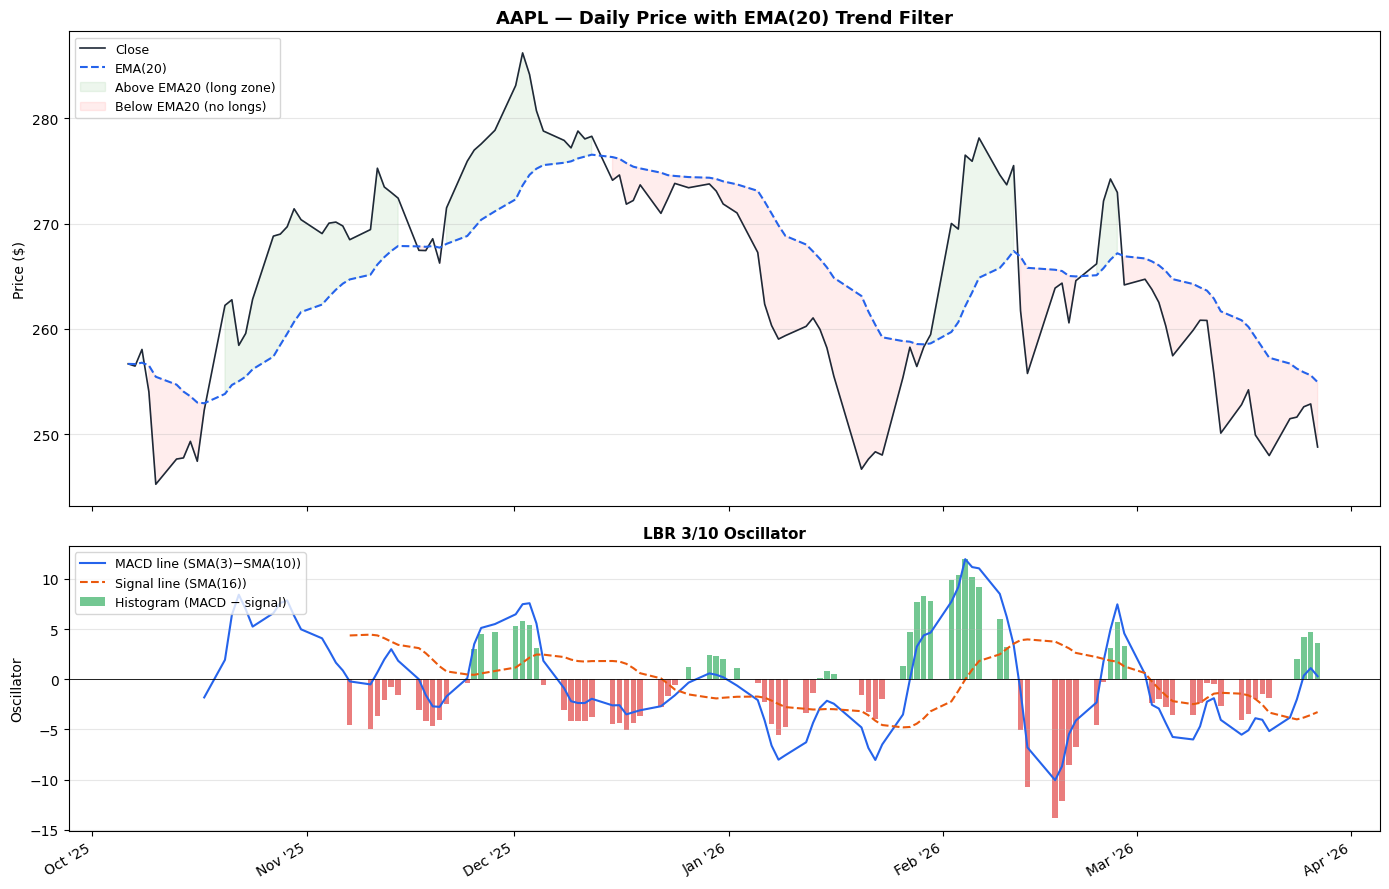


Latest oscillator values:
  MACD line   = 0.2987
  Signal line = -3.2724
  Histogram   = 3.5711  (prev: 4.6774)
  Hook up?    = False


In [46]:
closes_s     = pd.Series([d["close"]    for d in price_data])
dates_s      = pd.Series([d["datetime"] for d in price_data])
sma_fast     = closes_s.rolling(LBR_FAST).mean()
sma_slow     = closes_s.rolling(LBR_SLOW).mean()
macd_line    = sma_fast - sma_slow
signal_line  = macd_line.rolling(LBR_SIGNAL).mean()
histogram    = macd_line - signal_line
ema20_series = closes_s.ewm(span=EMA_PERIOD, adjust=False).mean()
# ── Plot ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1.2]})
# Top panel: price + EMA(20)
ax1.plot(dates_s, closes_s,     label="Close",    color="#1f2937", linewidth=1.2)
ax1.plot(dates_s, ema20_series, label="EMA(20)",  color="#2563eb", linewidth=1.5, linestyle="--")
ax1.fill_between(dates_s, closes_s, ema20_series,
                 where=(closes_s >= ema20_series), alpha=0.07, color="green", label="Above EMA20 (long zone)")
ax1.fill_between(dates_s, closes_s, ema20_series,
                 where=(closes_s < ema20_series),  alpha=0.07, color="red",   label="Below EMA20 (no longs)")
ax1.set_title(f"{DEMO_SYMBOL} — Daily Price with EMA(20) Trend Filter", fontsize=13, fontweight="bold")
ax1.set_ylabel("Price ($)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)
# Bottom panel: LBR oscillator
bar_colors = ["#16a34a" if h >= 0 else "#dc2626" for h in histogram.fillna(0)]
ax2.bar(dates_s, histogram, color=bar_colors, alpha=0.6, label="Histogram (MACD − signal)")
ax2.plot(dates_s, macd_line,   label="MACD line (SMA(3)−SMA(10))",  color="#2563eb", linewidth=1.5)
ax2.plot(dates_s, signal_line, label="Signal line (SMA(16))",        color="#ea580c", linewidth=1.5, linestyle="--")
ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_title("LBR 3/10 Oscillator", fontsize=11, fontweight="bold")
ax2.set_ylabel("Oscillator")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(axis="y", alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()
print("\nLatest oscillator values:")
print(f"  MACD line   = {macd_line.iloc[-1]:.4f}")
print(f"  Signal line = {signal_line.iloc[-1]:.4f}")
print(f"  Histogram   = {histogram.iloc[-1]:.4f}  (prev: {histogram.iloc[-2]:.4f})")
print(f"  Hook up?    = {histogram.iloc[-1] > histogram.iloc[-2]}")

---
# **SECTION 6: The 6 Anti Setup Rules**

The `calculate_lbr_signal()` function evaluates 6 rules in sequence — it **fails fast** on the first unmet condition.

```
Rule 1: Sufficient data         ≥ 31 bars required
Rule 2: ADX filter              ADX(14) ≤ 32  OR  not rising
Rule 3: Trend context           Close > EMA(20)
Rule 4: Signal line zero cross  Signal crossed above zero in last 16 bars AND currently above
Rule 5: Pullback                MACD line ≤ signal + 0.5×ATR  AND  MACD made a recent high
Rule 6: Hook                    Histogram ticking up  (hist_now > hist_prev)
```

All 6 must pass → `selected = True` → symbol enters the portfolio.

In [47]:
result = calculate_lbr_signal(DEMO_SYMBOL, price_data)

PASS = "✅"
FAIL = "❌"
SKIP = "⏭️"

def rule_status(condition, label, detail=""):
    icon = PASS if condition else FAIL
    print(f"  {icon}  {label}", end="")
    if detail:
        print(f"  →  {detail}", end="")
    print()

print(f"\n{'='*70}")
print(f"  Anti Setup Evaluation: {DEMO_SYMBOL}")
print(f"{'='*70}")

rule_status(len(price_data) >= LBR_MIN_BARS,
            f"Rule 1  Sufficient data",
            f"{len(price_data)} bars (need {LBR_MIN_BARS})")

rule_status(not (result['adx'] > 32 and result['adx_rising']),
            f"Rule 2  ADX filter",
            f"ADX={result['adx']:.1f}  rising={result['adx_rising']}")

rule_status(result['last_close'] > result['ema20'],
            f"Rule 3  Close > EMA(20)",
            f"close={result['last_close']:.2f}  ema20={result['ema20']:.2f}")

rule_status(result['signal_crossed'],
            f"Rule 4  Signal crossed zero from below")

rule_status(result['pullback'],
            f"Rule 5  MACD pulled back to signal")

if result['selected'] or result['skip_reason'] == "MACD histogram not yet hooking up — waiting for entry":
    hooking = result['selected']
    rule_status(hooking, "Rule 6  Histogram hooking up")
else:
    print(f"  {SKIP}  Rule 6  Histogram hook  (not reached)")

print(f"{'-'*70}")
if result['selected']:
    print(f"  ✅  SELECTED — Anti setup confirmed")
    print(f"     score={result['score']:.6f}  ATR=${result['atr']:.2f}")
else:
    print(f"  ❌  NOT SELECTED")
    print(f"     Reason: {result['skip_reason']}")
print(f"{'='*70}")


  Anti Setup Evaluation: AAPL
  ✅  Rule 1  Sufficient data  →  120 bars (need 31)
  ✅  Rule 2  ADX filter  →  ADX=22.3  rising=False
  ❌  Rule 3  Close > EMA(20)  →  close=248.80  ema20=254.96
  ❌  Rule 4  Signal crossed zero from below
  ❌  Rule 5  MACD pulled back to signal
  ⏭️  Rule 6  Histogram hook  (not reached)
----------------------------------------------------------------------
  ❌  NOT SELECTED
     Reason: price 248.80 below EMA20 254.96 — no long Anti


---
# **SECTION 7: Signal Scan — Magnificent 7**

The bot evaluates all 7 symbols every morning at 9:30 AM ET and selects those that pass all 6 rules.

- **0 selected** → hold cash, no trades
- **1–7 selected** → equal-weight allocation across selected symbols

> In production this runs inside `build_target_portfolio()` triggered by a CloudWatch cron.  
> Here we run it interactively — takes ~7 API calls (~10–20 seconds).

In [48]:
def scan_magnificent_7() -> tuple[list[str], dict[str, float]]:
    """
    Runs calculate_lbr_signal() on all 7 symbols.
    Returns (selected_symbols, atr_by_symbol).
    """
    signals = {}
    atrs    = {}
    for symbol in MAGNIFICENT_7:
        print(f"  Scanning {symbol}...", end=" ", flush=True)
        data = get_price_history(symbol)
        
        # Fail-fast: skip symbol if no data returned
        if not data:
            print(f"❌ NO DATA")
            continue
        
        result = calculate_lbr_signal(symbol, data)
        signals[symbol] = result
        atrs[symbol]    = result["atr"]
        status = "✅ SELECTED" if result["selected"] else f"❌"
        print(status)

    selected = [s for s, r in signals.items() if r["selected"]]
    return selected, {s: atrs[s] for s in selected}


Scanning Magnificent 7...

  Scanning AAPL... ❌
  Scanning MSFT... ❌
  Scanning NVDA... ❌
  Scanning GOOGL... ❌
  Scanning AMZN... ❌
  Scanning META... ❌
  Scanning TSLA... ❌

❌  No Anti setups confirmed — bot would hold cash today.


---
# **SECTION 8: Portfolio Math — Sizing and Diff**

Given selected symbols and total portfolio value, the bot computes:

1. **`_desired_positions()`** — equal-weight dollar allocation per symbol → integer share quantities  
2. **`_position_changes()`** — diff current holdings vs desired → what to sell and what to buy

Example: portfolio = $100,000, 3 symbols selected → $33,333 per symbol

In [49]:
if selected_symbols:
    print("Fetching live quotes for selected symbols...\n")
    portfolio_value   = Decimal("100000")
    desired           = _desired_positions(selected_symbols, portfolio_value)
    current_positions = {}   # assume flat (no open positions)
    sells, buys       = _position_changes(current_positions, desired)

    print(f"Portfolio value : ${portfolio_value:,}")
    print(f"Selected symbols: {selected_symbols}")
    print(f"Per-symbol alloc: ${portfolio_value / len(selected_symbols):,.0f}")
    print()
    print(f"Desired positions: {desired}")
    print(f"Sells            : {sells}")
    print(f"Buys             : {buys}")
else:
    print("❌  No symbols selected — no positions to size.")
    desired = {}
    buys    = {}

❌  No symbols selected — no positions to size.


---
# **SECTION 9: ATR Stop Placement**

For each new buy, the bot immediately places a **trailing stop-sell order** to protect the position.

```
stop_price  = ask − (ATR × 1.5)
trail_pct   = (ATR × 1.5) / ask × 100
target      = ask + (ATR × 1.5)        ← 1:1 R:R
```

**Why trailing vs fixed?**  
A trailing stop rises with price — it locks in profits as the stock moves up, while still giving room for normal intraday fluctuation.

> **Approximation note:**  
> Raschke places stops at swing lows identified from price structure.  
> `ATR × 1.5` is a computable proxy for volatility-adjusted risk.

In production, the stop order is placed via `TrailingStopOrderRequest` (regular hours).

In [50]:
if selected_symbols:
    print("Fetching live quotes for stop parameter calculation...\n")
    quotes = get_current_quotes(selected_symbols)
    print(f"{'Symbol':<8} {'Entry':>8} {'Stop':>8} {'Target':>8} {'Risk$':>7} {'Trail%':>8} {'ATR':>7}")
    print("-" * 65)
    for sym in selected_symbols:
        ask = quotes[sym]["askPrice"]
        atr = atr_by_symbol[sym]
        p   = calculate_stop_parameters(sym, ask, atr)
        print(f"{p['symbol']:<8} "
              f"${p['entry']:>7.2f} "
              f"${p['stop']:>7.2f} "
              f"${p['target']:>7.2f} "
              f"${p['risk_$']:>6.2f} "
              f"{p['trail_pct']:>7.2f}% "
              f"${p['atr']:>6.2f}")
else:
    print("❌  No symbols selected — no stops to place.")

❌  No symbols selected — no stops to place.


---
# **How This Runs in Production**

Everything above runs on AWS Lambda — invoked automatically every weekday morning.

```
CloudWatch cron (9:30 AM ET, Mon–Fri)
    │
    └─► Lambda: handler()
            │
            ├─ Get clock from Alpaca → skip if market closed
            ├─ build_target_portfolio()  ← signal scan (this notebook, Sections 1–7)
            ├─ Cancel stale open orders
            ├─ Compute desired positions  (Section 8)
            ├─ Execute SELL orders → wait 2s → execute BUY orders
            ├─ Place ATR trailing stop for each buy  (Section 9)
            └─ Save portfolio state to DynamoDB
```

**Functions NOT shown in this notebook** (AWS infrastructure only):

| Function | Why excluded |
|----------|--------------|
| `handler()` | Lambda entry point — requires CloudWatch event context |
| `_store_portfolio()` / `_get_portfolio()` | DynamoDB — needs AWS credentials and table |
| `place_market_order()` / `place_trailing_stop_order()` | Submits real orders — not for notebook demo |
| `cancel_order()` | Modifies live account state |
| `_get_clients()` | SSM Parameter Store — uses IAM role attached to Lambda |

---

### Real-Time Quote Streaming

The notebook includes a real-time quote streaming setup. To enable it, modify the code below to subscribe to quotes:

```python
# (Optional) To start streaming quotes in production:
# stream.subscribe_quotes(handle_quote, *MAGNIFICENT_7)
# await stream.run()
```

This allows the trading bot to react to market updates in real-time via WebSocket connections.

**Source code:** `main.py` + `alpaca_broker.py` in the project root.  
**Architecture diagrams:** `architecture-flow.mmd` (flow) and `architecture-infra.mmd` (infra).